In [1]:
#Loading in Packages and Data

#Importing Packages
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import ScalarFormatter
import matplotlib.gridspec as gridspec
import xarray as xr
import os; import time
import pickle
import h5py
###############################################################
def coefs(coefficients,degree):
    coef=coefficients
    coefs=""
    for n in range(degree, -1, -1):
        string=f"({coefficients[len(coef)-(n+1)]:.1e})"
        coefs+=string + f"x^{n}"
        if n != 0:
            coefs+=" + "
    return coefs
###############################################################

# Importing Model Data
check=False
dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'

# dx = 1 km; Np = 1M; Nt = 5 min
data=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_1km_5min.nc', decode_timedelta=True) #***
parcel=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_pdata_1km_5min_1e6.nc', decode_timedelta=True) #***
res='1km';t_res='5min'
Np_str='1e6'

# # dx = 1km; Np = 50M
# #Importing Model Data
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_1km_1min.nc', decode_timedelta=True) #***
# parcel=xr.open_dataset(dir2+'cm1out_pdata_1km_1min_50M.nc', decode_timedelta=True) #***
# res='1km'; t_res='1min'; Np_str='50e6'

# # dx = 1km; Np = 50M; Nz = 95
# #Importing Model Data
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_1km_1min_95nz.nc', decode_timedelta=True) #***
# parcel=xr.open_dataset(dir2+'cm1out_pdata_1km_1min_95nz.nc', decode_timedelta=True) #***
# res='1km'; t_res='1min_95nz'; Np_str='50e6'

# # dx = 250km; Np = 50M 
# #Importing Model Data
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_250m_1min_50M.nc', decode_timedelta=True) #***
# parcel=xr.open_dataset(dir2+'cm1out_pdata_250m_1min_50M.nc', decode_timedelta=True) #***
# res='250m'; t_res='1min'; Np_str='50e6'

In [2]:
#LOAD VARIABLES
################################################################################
def load_vars(data):
    
    ###########################
    # Equivalent Potential Temperature (theta_e)
    # surface_prs=data['prs'].mean(dim=("time",'yh','xh')); surface_prs=surface_prs[0]
    
    
    # print('PRESSURE VARIABLES'); ################################# PRESSURE VARIABLES
    p0=1e5
    P=data['prs'].data
    
    # print('MIXING RATIO'); ################################# MIXING RATIO
    rv=data['qv'].data
    rt=(data['qv']+data['qc']+data['qr']).data #total mixing ratio
    
    # print('THERMODYNAMICS'); ################################# THERMODYNAMICS
    Rd=287.04
    Rv=461.5
    Cpd=1005.7 #+-2.5
    Cpv=1870 #+-25
    Cpl=4190 #+-30 #Cl=Cpl=Cvl (same as constant pressure or volume)
    Lv0=2.501e6
    def Lv(T): #Kirchoff's formula L_i,ii= L_i,ii0+(Cpii-Cpi)*(T-273.15)
        Llv=Lv0+(Cpv-Cpl)*(T-273.15) #should it be Cpl. is Cl the same?***
        return Llv

    Lf0 = 0.3337e6  # latent heat of fusion at 0°C
    Cpi=2106.0 #+-6 #Ci=Cpi=Cvi (same as constant pressure or volume)
    def Lf(T):
        return Lf0 + (Cpl - Cpi) * (T - 273.15) 
    def Ls(T):
        return Lv(T) + Lf(T) # Lv(T) + Lf(T)
    
    # print('TEMPERATURE'); ################################# TEMPERATURE
    theta=data['th'].data
    T=theta*(P/p0)**(Rd/Cpd)
    
    # print('RELATIVE HUMIDITY'); ################################# RELATIVE HUMIDITY
    eps=0.622
    #rv=eps*(e/(P-e)) ==> e = rv*P/(eps+rv)
    e=rv*P/(rv+eps)
    Pd=P-e #P=Pd+e ==> Pd=P-e

    #CALCULATING VAPOR PRESSURE AND RELATIVE HUMIDITY OVER VAPOR PRESSURE
    def VaporPressure(T):
        e_s0=611
        T0=273.15
        inner=(Lv(T)/Rv)*((1/T0)-(1/T))
        e_s=e_s0*np.exp(inner)
        return e_s
    e_s = VaporPressure(T)
    H_vapor = e/e_s 

    #CALCULATING RELATIVE HUMIDITY OVER ICE
    def IceSaturationPressure(T):
        e_s0 = 611  # same reference vapor pressure at 0°C (Pa)
        T0 = 273.15
        inner_ice = (Ls(T) / Rv) * ((1 / T0) - (1 / T))
        e_si = e_s0 * np.exp(inner_ice)
        return e_si
    ei_s = IceSaturationPressure(T)
    H_ice = e / ei_s

    return P, p0, rv, rt, Rd, Rv, Cpd, Cpv, Cpl, Lv, T, e, Pd, e_s, H_vapor, H_ice

In [3]:
def make_theta_e(P, p0, rv, rt, Rd, Rv, Cpd, Cpv, Cpl, Lv, T, e, Pd, e_s, H_vapor, H_ice):
    divisor=(Cpd+Cpl*rt)
    theta_e=(T*(p0/Pd)**(Rd/divisor))*(H_vapor**(-rv*Rv/divisor))*np.exp(Lv(T)*rv/(divisor*T))

    return {
        'theta_e': theta_e,
        'RH_vapor': H_vapor,
        'RH_ice': H_ice
    }

In [4]:
def GetOutputName():
    if res=='1km':
        dir2='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
    elif res=='250m':
        dir2='/mnt/lustre/koa/scratch/air673/'
    out_file = dir2 + 'Variable_Calculation/OUTPUT/' + f'theta_e_{res}_{t_res}.h5'
    return out_file
    
def initiate_array(VarNames):
    # Define array dimensions (adjust based on your data)
    t_size = len(data['time'])  # Number of timesteps
    z_size = len(data['zh'])    # Number of vertical levels
    y_size = len(data['yh'])    # Number of y-axis points
    x_size = len(data['xh'])    # Number of x-axis points

    out_file=GetOutputName()

    with h5py.File(out_file, 'a') as f:
        for var_name in VarNames:
            if var_name not in f:
                f.create_dataset(
                    var_name,
                    shape=(t_size, z_size, y_size, x_size),
                    maxshape=(None, z_size, y_size, x_size),
                    dtype='float64',
                    chunks=(1, z_size, y_size, x_size)
                )

def add_timestep_at_index(VARS, index, ):
    out_file=GetOutputName()
    
    with h5py.File(out_file, 'a') as f:
        for var_name, timestep_data in VARS.items():
            if var_name in f:
                f[var_name][index] = timestep_data
            else:
                raise KeyError(f"Dataset '{var_name}' does not exist in {out_file}")

In [5]:
####################################
#RUNNING

In [ ]:
#MAKING ARRAY TO STORE THETA_E
#MAKING ARRAY TO STORE BUOYANCY
VarNames=['theta_e','RH_vapor','RH_ice']
initiate_array(VarNames)

#CALCULATING AND APPENDING TO DATA EACH TIMESTEP
for t in range(len(data['time'])):
    if np.mod(t,1)==0: print(f'Current time {t}')
    data_t=data.isel(time=t)
    [P, p0, rv, rt, Rd, Rv, Cpd, Cpv, Cpl, Lv, T, e, Pd, e_s, H_vapor, H_ice] = load_vars(data_t)
    VARS=make_theta_e(P, p0, rv, rt, Rd, Rv, Cpd, Cpv, Cpl, Lv, T, e, Pd, e_s, H_vapor, H_ice)
    add_timestep_at_index(VARS, t)


#Fast for 1KM, 1.5 hours for 250M

Current time 0
Current time 1
Current time 2
Current time 3
Current time 4
Current time 5
Current time 6
Current time 7
Current time 8
Current time 9
Current time 10
Current time 11
Current time 12
Current time 13
Current time 14
Current time 15
Current time 16
Current time 17
Current time 18
Current time 19
Current time 20
Current time 21
Current time 22
Current time 23
Current time 24
Current time 25
Current time 26
Current time 27
Current time 28
Current time 29
Current time 30
Current time 31
Current time 32
Current time 33
Current time 34
Current time 35
Current time 36
Current time 37
Current time 38
Current time 39
Current time 40
Current time 41
Current time 42
Current time 43


In [ ]:
##########################################################################

In [ ]:
# #READING FINAL OUTPUT
# # dir2='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
# dir2='/mnt/lustre/koa/scratch/air673/'
# with h5py.File(dir2 + 'Variable_Calculation/' + 'theta_e_{res}_{t_res}.h5', 'a') as f:
#     # Access the existing dataset 'MSE'
#     dataset = f['theta_e'][:]

In [ ]:
#TESTING
########################################################################

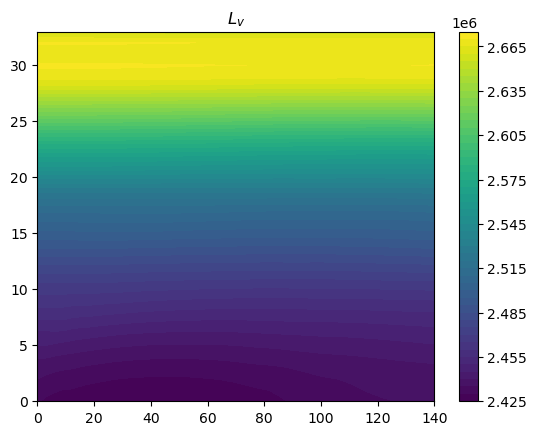

In [3]:
# LV=Lv(T)
# mean=np.mean(LV,axis=(2,3))
# plt.contourf(mean.T,levels=50)
# plt.colorbar();
# plt.title(r'$L_v$');

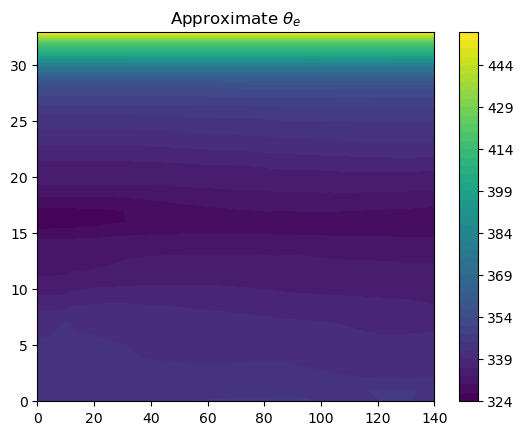

In [4]:
#MAKING APPROXIMATE THETA_E

# divisor=(Cpd+Cpl*qt)
# theta_e_approx=theta*np.exp(Lv(T)*qv/(divisor*T))
# mean=np.mean(theta_e_approx,axis=(2,3))
# plt.contourf(mean.T,levels=50)
# plt.colorbar();
# plt.title('Approximate ' + r'$\theta_e$');x

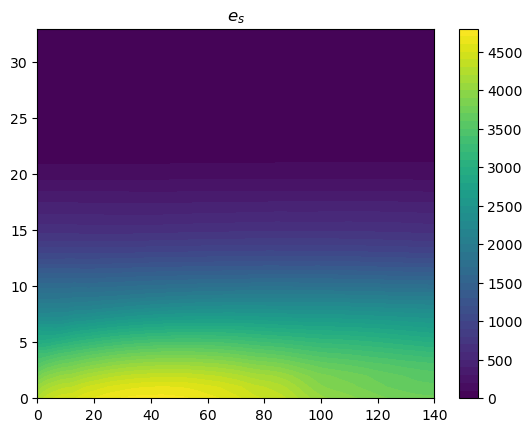

In [5]:
# mean=np.mean(e_s,axis=(2,3))
# plt.contourf(mean.T,levels=50)
# plt.colorbar();
# plt.title(r'$e_sx$');

In [50]:
# print('FULL THETA_E') # MAKING FULL THETA_E

# def make_theta_e():
#     divisor=(Cpd+Cpl*qt)
#     theta_e=(T*(p0/Pd)**(Rd/divisor))*(H**(-qv*Rv/divisor))*np.exp(Lv(T)*qv/(divisor*T))
#     return theta_e

# theta_e=make_theta_e()

# # mean=np.mean(theta_e,axis=(2,3))
# # plt.contourf(mean.T,levels=50)
# # plt.colorbar();
# # plt.title('Non-approximate ' + r'$\theta_e$');

Text(0.5, 1.0, 'comparing non-approximate minus approximate $\\theta_e$')

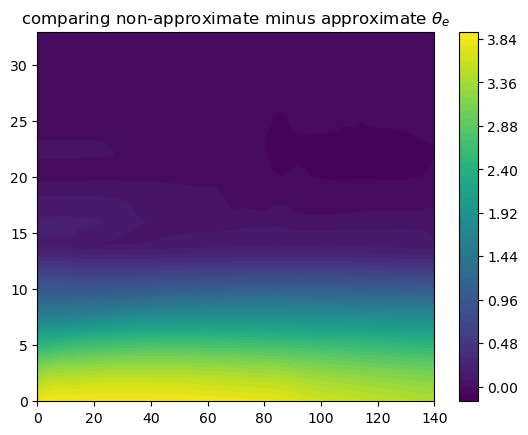

In [7]:
# hey=np.mean((theta_e-theta_e_approx),axis=(2,3))
# plt.contourf(hey.T,levels=50)
# plt.colorbar()
# plt.title('comparing non-approximate minus approximate ' + r'$\theta_e$')

In [67]:
# vert_mean1=np.mean(theta_e_approx,axis=(0,2,3))
# vert_mean2=np.mean(theta_e,axis=(0,2,3))

# plt.plot(vert_mean1,data['zh'],label='approx')
# plt.plot(vert_mean2,data['zh'],label='non-approx')
# plt.legend();
# plt.title('comparing approx and non-approximate ' + r'$\theta_e$') #most difference at the surface 
# #conclusion: use non-approximated version 
# plt.xlim((320,380))

In [ ]:
# #MAKING ARRAY TO STORE THETA_E
# #RUNNING
# initiate_array()

# #CALCULATING AND APPENDING TO DATA EACH TIMESTEP
# for t in range(len(netCDF['time'])):
#     if np.mod(t,1)==0: print(f'Current time {t}')
#     data=netCDF.isel(time=t)
#     [P, p0, qv, qt, Rd, Rv, Cpd, Cpv, Cpl, Lv, T, e, Pd, e_s, H] = load_vars(data)
#     theta_e=make_theta_e(P, p0, qv, qt, Rd, Rv, Cpd, Cpv, Cpl, Lv, T, e, Pd, e_s, H)
#     add_timestep_at_index(theta_e, t)


# #Fast for 1KM, 1.5 hours for 250M